# <p align = "center"> Conformation Analysis </p>


In [1]:
from pathlib import Path
rootdir = Path("../../../..").resolve()
import sys
sys.path.insert(0, str(rootdir) )
from typing import Callable, Generator

import gemmi 
import parasail
import numpy as np
from rdkit import Chem

from xaidar.data.molecModels import get_pdb_stats, sele_pdb, sele_Lig, get_res_CoM
from xaidar.data.molecModels import flatten_pdb, sele_AA, createPDB, get_atom_coord

## Functions Created During this Notebook

In [162]:
def sele_closest_Chain( lst_chains: list[gemmi.Chain], 
                       CoM: gemmi.Position , verbose = False) -> list[gemmi.Chain]:
    
    """
    Select the chain that contains the ligand and is closest to the CoM
    of the protein.
    Args:
    - lst_chains (list[gemmi.Chain]): List of chains in the PDB.
    - CoM (gemmi.Position): Center of Mass of the protein.
    - ligLabel (str, optional): Ligand residue name. Defaults to "LIG".
    Returns:
    - list[gemmi.Chain]: List containing the selected chain.
    """
    if len(lst_chains) == 1:
        if verbose: print("Only one chain in the PDB, returning it")
        return lst_chains
    else:
        # Select the chain closest to the CoM
        min_dist = float('inf')
        selected_chain = None
        for chain in lst_chains:
            dist = chain.calculate_center_of_mass().dist(CoM)
            if dist < min_dist:
                min_dist = dist
                selected_chain = chain
        return [selected_chain]

# prot = sele_pdb( prot, "chain", sele_closest_Chain, lig_com )
# prot2 = sele_pdb( prot2, "chain", sele_closest_Chain, lig_com )
# get_pdb_stats( pdb )
# print("")
# get_pdb_stats( pdb2 )

In [ ]:
class seqAlign():
    def __init__( self, refseq: str, queryseq: str, sanityCheck: bool = True): 
        self.refseq = refseq
        self.queryseq = queryseq
        self.result = None                                                       # parasail alignment result object
        self.reverseQuery = False
        self.sanityCheck = sanityCheck
        self.matched_indices = None                                              # Dictionary of matched indices and AAs {"Ref":{"Seq_Idx":None, "Seq_AA":None }, "Query":{"Seq_Idx":None, "Seq_AA":None }}
        if sanityCheck:                                                                                                 
            self.find_orientation()
            if self.reverseQuery: print("Warning: Query sequence reversed for better alignment")

    def align( self, mode: str = "global", gap_open: int = 10, gap_extend: int = 1,
              matrix: str = "blosum62"):
        if mode == "global":
            self.result = parasail.nw_trace_striped_32( self.queryseq, self.refseq, gap_open, gap_extend,
                                      getattr( parasail, matrix) )
        elif mode == "local":
            self.result = parasail.sw_trace_striped_32( self.queryseq, self.refseq, gap_open, gap_extend,
                                      getattr( parasail, matrix))
        else:
            raise ValueError("Invalid mode. Choose 'global' or 'local'.")
        
        return self
    
    def find_orientation( self, mode: str = "global", gap_open: int = 10, gap_extend: int = 1,
              matrix: str = "blosum62"):
        """
        Find if the best alignment is obtained by reversing the query sequence.
        """
        normalScore = self.align(mode = mode, gap_open = gap_open, 
                    gap_extend = gap_extend,matrix = matrix).result.score
        self.queryseq = self.queryseq[::-1]
        reverseScore = self.align(mode = mode, gap_open = gap_open, 
                    gap_extend = gap_extend,matrix = matrix).result.score
        if reverseScore > normalScore:
            self.reverseQuery = True
        else:
            self.queryseq = self.queryseq[::-1]
            self.align(mode = mode, gap_open = gap_open, 
                    gap_extend = gap_extend,matrix = matrix)
            self.reverseQuery = False
            # self.queryseq = self.queryseq[::-1]                                       # Restore original query

    def match_indices( self):
        if self.result is None:
            raise ValueError("Alignment not performed yet. Call align() first.")
        matches = {"Ref":{"Seq_Idx":None, "Seq_AA":None },
                   "Query":{"Seq_Idx":None, "Seq_AA":None }}
        comp_matchIndex = [ idx for idx, char in                                # Get indices of matches in comparison string
                           enumerate(self.result.traceback.comp) if char == '|']
        
        def seq_match_idx( seq: str, matchIdx: list[int]) -> list[int]:         # Helper function to get indices
            gapCount = 0
            seq_indices = []
            for seq_idx, char in enumerate(seq):
                if char == '-':
                    gapCount += 1
                if seq_idx in matchIdx:
                    seq_indices.append(seq_idx - gapCount)
            return seq_indices
        
        refSeq_matchIdx = seq_match_idx( self.result.traceback.ref,comp_matchIndex)
        matches["Ref"]["Seq_Idx"] = refSeq_matchIdx 

        queryseq_matchIdx = seq_match_idx( self.result.traceback.query,comp_matchIndex)
        matches["Query"]["Seq_Idx"] = queryseq_matchIdx

        refSeq_matchAA = [ self.refseq[idx] for idx in refSeq_matchIdx ]
        matches["Ref"]["Seq_AA"] = refSeq_matchAA 

        queryseq_matchAA = [ self.queryseq[idx] for idx in queryseq_matchIdx ]
        matches["Query"]["Seq_AA"] = queryseq_matchAA 
        
        self.matched_indices = matches

        return self

    def visualize( self):
        if self.result is None:
            raise ValueError("Alignment not performed yet. Call align() first.")
        comp_size = len(self.result.traceback.comp)
        count = list( " "*comp_size )
        for idx in range(comp_size):
            if idx % 100 - 99 == 0 and idx != 0: count[idx] = "+"
            elif idx % 50 - 49 == 0 and idx != 0: count[idx] = "*"
            elif idx % 10 - 9 == 0 and idx != 0: count[idx] = "|"
        count = "".join(count)
        
        print("      ", count)
        print("Ref:  ", self.result.traceback.ref)
        print("      ", self.result.traceback.comp)
        print("Query:", self.result.traceback.query)
        
    

In [164]:
# Test Dataset
ref = "GKGDPKKPRGKMSSYAFFVQTSREEHKKKHPDASVNFSEFSKKCSERWKTMSAKEKGKFEDMAKADKARYEREMKTYIPPKGE"
seq2 = "MVKVLGAGGQIAANRVKVEFKNDPSISELASLVKSQKVTVRGGNKMELQFRGKGYVGEVKEGEEVEGKNKPEEKHD"
seq3 = ref[::-1] # Reverse of ref
seq4 = "PRGKMSSYAFFVQTSREEHKKKHPDASVNFSEFSK"
seq4 = "PRGKMSSYAFFV121QTSREEHK2312KKHPD12321ASVNFSEFSK" # Introduced gaps
seq5 = "KKPRGKMSSYAFFVQTSREEHKKKHPDASVNFSEF"
seq5 = "KKPRGKMSSYAFHPDASVNFSEFFVQTSREEHKKKHPDASVNFSEF" # Introduced repetition


In [165]:
print( len(ref), len(seq2) )

# alignment = seqAlign( ref, seq2, sanityCheck=False)

# print( alignment.align().match_indices().matched_indices )
# alignment.visualize()

alignment = seqAlign( ref, seq2, sanityCheck=False).align().visualize()
alignment = seqAlign( ref, seq2[::-1], sanityCheck=False).align().visualize()


83 76
Ref:   GKGDPKKPRGKMSSYAFFVQTSREEHKKKHPDASVNFSEFSKKCSERWKTMSAKEKGKFEDMAKA----DKARYEREMKTYIPPKGE
               ..|:......:..:|.:.:.|: |.|:  ||.:.....:..|:....|.:.:...|.    .|...|.|.|.....|.:
Query: --------MVKVLGAGGQIAANRVKVEFKN-DPSI--SELASLVKSQKVTVRGGNKMELQFRGKGYVGEVKEGEEVEGKNKPEEKHD
Ref:   GKGDPKKPRGKMSSYAFFVQTSREEHKKKHPDASVNFSEFSKKCSERWKTMSAKEKGKFEDMAKADKARYEREMKTYIPPKGE------
       ...:..|.:|::           ||.:|..........:...|...|.....:|.....|.::..:|  :|.:::......|.      
Query: DHKEEPKNKGEV-----------EEGEKVEGVYGKGRFQLEMKNGGRVTVKQSKVLSALESISPDNK--FEVKVRNAAIQGGAGLVKVM


### Looking at natural flexibility of Ground-state Active Site

- RMSD

In [2]:
# Load Fragalysis data (nonactivepdbs_dir, fragscreen_dir, piperid_dir, ...)

# 1. Loading Fragalyis data Root Directory
rootProjDir = rootdir / "data/ev2a/fragalysis"
fragalysisDir =  rootdir / "data/ev2a/fragalysis"

# 2. Load Fragalysis Protein Directories
nonactivepdbs_dir = fragalysisDir / "02-chemofint/nonactivesite"
fragscreen_dir = fragalysisDir / "02-chemofint/fragscreen"
piperid_dir = fragalysisDir / "02-chemofint/piperid"

# 3. Load Fragalysis Ligand Files
fragScreenLigPath = fragalysisDir / "02-chemofint/fragscreen_lig.sdf"
fragScreenLigs = Chem.SDMolSupplier( str(fragScreenLigPath), removeHs=False)
piperidLigPath = rootProjDir / "02-chemofint/piperidir_lig.sdf"
piperidLigs = Chem.SDMolSupplier( str(piperidLigPath), removeHs=False)


In [3]:
# Load test datasets (testDiProt)

testDiProt=gemmi.read_pdb(str(nonactivepdbs_dir/"A0202a/A0202a_apo-desolv.pdb"))

In [3]:
# Calculate mean CoM for all ligands (mean_CoM)

lig = piperidLigs[0]
lst_ligs = []
for lig in piperidLigs:
    if lig is not None:
        lig_atoms = flatten_pdb(gemmi.read_pdb_string(                          # Convert RDKit Mol to Gemmi Structure
                            Chem.MolToPDBBlock( lig) ), "residue")[0]
        lst_ligs.append( lig_atoms )


CoM_array = get_res_CoM(  lst_ligs  )
print( "Ligands CoM array shape: ", CoM_array.shape)
mean_CoM = CoM_array.mean(axis=0)
mean_CoM = gemmi.Position( *mean_CoM )
print( "Mean CoM from all ligands: ",mean_CoM )

Ligands CoM array shape:  (460, 3)
Mean CoM from all ligands:  <gemmi.Position(8.93134, 13.2798, 23.3181)>


In [4]:
# Filter Protein Sequences to only those with ligands within 8A of mean CoM -> lst_prots


testDiProt=gemmi.read_pdb(str(nonactivepdbs_dir/"A0202a/A0202a_apo-desolv.pdb"))


In [4]:
# Filter Protein Sequences to only those with ligands within 8A of mean CoM -> (lst_prots, prot_logs)
from xaidar.data.molecModels import sele_closest_Chain
# Test datasets
ieDatasets = [ "A0926a", "A0202a"]
ieFileTypes = ["piperid","nonactive"]
datasets = ieDatasets
fileTypes = ieFileTypes

# Full datasets
datasets = [ dataset.name for dataset in nonactivepdbs_dir.iterdir()            # Initial variables
            if dataset.is_dir() ]
fileTypes = ["nonactive"] * len(datasets)



def load_and_filter_Proteins( datasets_dir: Path,
                             coord: gemmi.Position ,
                             ) -> tuple[list[gemmi.Structure], dict]:
    """
    Load and filter protein structures based on proximity to a given center of mass (CoM).
    Args:
    - datasets (list[str]): List of dataset names.
    - fileTypes (list[str]): List of file types corresponding to each dataset.
    - mean_CoM (tuple[float,float,float], optional): Center of Mass coordinates. 
            Defaults to mean_CoM.

    Returns:
    - tuple[list[gemmi.Structure], dict]: Tuple containing the list of filtered 
    protein structures and a log dictionary with stats.     
    """
    lst_prots = []                                                                # List to Save filtered proteins
    prot_logs = { "sequence": [], "chainSize":[], "NumChains":[], "NumModels":[]} # Log dictionary with stats for filtered proteins
    
    datasets = [ dataset.name for dataset in datasets_dir.iterdir()            
            if dataset.is_dir() ]
    for dataset in datasets:                                                    # Loop over datasets

        pdb = gemmi.read_pdb( str(datasets_dir /                                # Load PDB
                                    "{}/{}.pdb".format(dataset, dataset) ))

                                                                                # Filtering
        allProts = sele_pdb( pdb, sele_AA)                                          # Get a.a.s (all models and chains and residues that are a.a.s)
        prot_chainList=sele_closest_Chain(flatten_pdb(allProts,"chain"), coord)     # Get chains closest to mean CoM
                                                                                
        prot = allProts.clone()                                                 # Save selected chains in new structure
        chain_names = [ chain.name for chain in prot[0]]
        for chain_name in chain_names: del  prot[0][chain_name[0]]                  # Create empty structure, delete all chains 
        for chain in prot_chainList: prot[0].add_chain( chain)                      # Add selected chains to new structure
                                                                                # Log stats for filtered proteins                 
        startChain = [ chain.name for chain in prot[0]][0]
        prot_logs["sequence"].append( "".join([ res.name for res                    # Get sequence of first chain
                                            in prot[0][startChain].whole()]) )
        prot_logs["chainSize"].append( len(prot[0][startChain]) )                   # Get size of first chain            
        prot_logs["NumChains"].append( len(prot[0]) )                               # Get number of chains                      
        prot_logs["NumModels"].append( len(prot) )                                  # Get number of models 
        lst_prots.append( prot)

    return lst_prots, prot_logs


nonactive_prots, nonactive_logs = load_and_filter_Proteins( nonactivepdbs_dir, 
                                                                    mean_CoM )
fragscreen_prots, fragscreen_logs = load_and_filter_Proteins( fragscreen_dir, 
                                                                    mean_CoM )
piperid_prots, piperid_logs = load_and_filter_Proteins( piperid_dir, 
                                                                    mean_CoM )

print("\t\t       #Dirs  #AfterFilter")
print( "Nonactive Proteins:\t{}\t{}".format(len(list(nonactivepdbs_dir.iterdir())),
                                             len(nonactive_prots)))
print("FragScreen Proteins:\t{}\t{}".format(len(list(fragscreen_dir.iterdir())),
                                            len(fragscreen_prots)))
print("Piperid Proteins:  \t{}\t{}".format(len(list(piperid_dir.iterdir())),
                                           len(piperid_prots)))


		       #Dirs  #AfterFilter
Nonactive Proteins:	99	99
FragScreen Proteins:	42	42
Piperid Proteins:  	454	454


# A.A. Chain Sanity Check 

In [5]:
# Check consistency of filtered proteins (lst_prots, prot_logs)
    # Expected Properties: Number of chains = 1, Number of models = 1, Chain size = 140
for lst_prots, prot_logs, name in zip([nonactive_prots, fragscreen_prots, piperid_prots]
                                      ,[nonactive_logs, fragscreen_logs, piperid_logs],
                                        ["Nonactive", "FragScreen", "Piperid"]):
    print("\nChecking consistency of {} filtered proteins".format(name))
    lst_sizes, lst_seqs, lst_chains, lst_models = [ list(set( prot_logs["chainSize"])), 
    list(set( prot_logs["sequence"])), list(set(prot_logs["NumChains"])), list(set( prot_logs["NumModels"])) ]

    if len(lst_sizes) > 1 or len(lst_seqs) > 1 or len(lst_chains) > 1 or len(lst_models) > 1:
        print("Warning: Inconsistent number of chains or models in the selected proteins")
        print("Chain sizes: ", lst_sizes)
        print("Number of models: ", lst_models)
        # print( "Sequences: ", lst_seqs)
    elif lst_sizes[0] != 140 or lst_chains[0] != 1 or lst_models[0] != 1:
        print("Warning: Unexpected number of chains or models in the selected proteins")
        print("Chain sizes: ", lst_sizes)
        print("Number of chains: ", lst_chains)
        print("Number of models: ", lst_models)
    else:
        print("All selected proteins have consistent number of chains and models")
        print("Chain sizes: ", lst_sizes[0])
        print("Number of chains: ", lst_chains[0])
        print("Number of models: ", lst_models[0])

    count_dict = dict( zip(lst_sizes, [0]*len(lst_sizes) ) )
    for size in prot_logs["chainSize"]: count_dict[size] += 1

    title = "Size: "
    for size in lst_sizes: title += " {}\t|".format(size)

    count = "Count: "
    for size in lst_sizes: count += " {}\t|".format(count_dict[size])
    
    index = "Eg Idx:"
    for size in lst_sizes: index += " {}\t|".format(prot_logs["chainSize"].index(size))
    print( title)
    print( count)
    print( index)


    # prot138, prot139, prot140, prot141 = [ lst_prots[44], lst_prots[3], lst_prots[00],
    #                                     lst_prots[30] ]


Checking consistency of Nonactive filtered proteins
Chain sizes:  [138, 139, 140, 141]
Number of models:  [1]
Size:  138	| 139	| 140	| 141	|
Count:  2	| 20	| 74	| 3	|
Eg Idx: 44	| 3	| 0	| 30	|

Checking consistency of FragScreen filtered proteins
Chain sizes:  [138, 139, 140]
Number of models:  [1]
Size:  138	| 139	| 140	|
Count:  3	| 11	| 28	|
Eg Idx: 13	| 1	| 0	|

Checking consistency of Piperid filtered proteins
Chain sizes:  [138, 139, 140]
Number of models:  [1]
Size:  138	| 139	| 140	|
Count:  14	| 364	| 76	|
Eg Idx: 58	| 0	| 8	|


### Perform Sequence Alignment

In [6]:
from xaidar.data.molecModels import model_seqAlign
nonactive_idx, fragscreen_idx, piperid_idx = [44 , 3, 0	,30], [13, 1, 0] , [58, 0, 8]
idx1, idx2 = nonactive_idx[:2]

lst_prots = nonactive_prots
alignment = model_seqAlign( lst_prots[30], lst_prots[0]).align().visualize().check_match()


                |         |         |         |         *         |         |         |         |         +         |         |         |         | 
Ref:   SGAIYVGNYRVVNRHLATHNDWANLVWEDSSRDLLVSSTTAQGCDTIARCNCQTGVYYCSSKRKHYPVSFTKPSLIFVEASEYYPARYQSHLMLAVGHSEPGDCGGILRCQHGVVGIVSTGGNGLVGFADVRDLLWLDDEA
       ||||||||||||||||||||||||||||||||||||||||||||||||||:||||||||||:||||||||:|||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||:| 
Query: SGAIYVGNYRVVNRHLATHNDWANLVWEDSSRDLLVSSTTAQGCDTIARCDCQTGVYYCSSRRKHYPVSFSKPSLIFVEASEYYPARYQSHLMLAVGHSEPGDCGGILRCQHGVVGIVSTGGNGLVGFADVRDLLWLDEE-
Mismatch in residue serial numbers between reference and query.


In [7]:
lst_prots = nonactive_prots
num_chains = len(lst_prots)
mismatch_lst = []
for i in range(num_chains):
    for j in range(i+1, num_chains):
        alignment_result = model_seqAlign( lst_prots[i], lst_prots[j]).check_match(verbose=False).match_status
        if not alignment_result: mismatch_lst.append( (i,j) )

print("Number of mismatches found:{} / {} ".format(len(mismatch_lst),num_chains*(num_chains-1)//2 ))

Number of mismatches found:2132 / 4851 


### Checking Amino Acid Distribution Variation across Different Chains

In [8]:
# Pick Largest Chain as Reference Chain
from xaidar.data.molecModels import get_chain_seq
ref_seq = get_chain_seq( flatten_pdb(lst_prots[30], "chain") )[0]
print("Reference Sequence (Prot idx 30):\n", ref_seq)
print( len(ref_seq) )
ref_seq[140]

Reference Sequence (Prot idx 30):
 SGAIYVGNYRVVNRHLATHNDWANLVWEDSSRDLLVSSTTAQGCDTIARCNCQTGVYYCSSKRKHYPVSFTKPSLIFVEASEYYPARYQSHLMLAVGHSEPGDCGGILRCQHGVVGIVSTGGNGLVGFADVRDLLWLDDEA
141


'A'

In [9]:
# Comparing 
all_query_seqs = []
lst_prots = nonactive_prots
for lst_prots in [nonactive_prots, fragscreen_prots, piperid_prots]:
    num_chains = len(lst_prots)
    query_seqs = []
    for i in range(num_chains):
        # if i != 30 and name != "nonactive": # includes reference into query seqs
        alignment = model_seqAlign( nonactive_prots[30], lst_prots[i]).check_match(verbose=False)
        alignment_result = alignment.match_status
        ref_seq = alignment.result.traceback.ref
        ref_seq_gaps = [ idx for idx, char in enumerate(ref_seq) if char == '-']
        query_seq = alignment.result.traceback.query
        query_seq = [ char for idx, char in enumerate(query_seq) if idx not in ref_seq_gaps ]
        query_seq_str = "".join( query_seq )
        query_seqs.append( query_seq_str )
    all_query_seqs.append( query_seqs )           

In [10]:
for query_seqs, name in zip( all_query_seqs, 
                            ["Nonactive", "FragScreen", "Piperid"] ):
    print("\nAnalyzing sequence variability in {} dataset".format(name))
    order_seq_lst = list( zip( *query_seqs)  )
    order_seq_sets = [ set( seqs) for seqs in order_seq_lst ]
    multiple_aa_pos = [ (idx, aa_set) for idx, aa_set in enumerate(order_seq_sets) if len(aa_set) > 1 ]
    # print("\t", order_seq_sets[:5] )
    print("\tPositions with multiple AAs across sequences:")
    for pos, aa_set in multiple_aa_pos:
        print("\tPosition {}: AAs {}".format(pos + 1, aa_set) )

flat_all_query_seqs = [ seq for sublist in all_query_seqs for seq in sublist ]
print("\nAnalyzing sequence variability in all dataset")
order_seq_lst = list( zip( *flat_all_query_seqs)  )
order_seq_sets = [ set( seqs) for seqs in order_seq_lst ]
multiple_aa_pos = [ (idx, aa_set) for idx, aa_set in enumerate(order_seq_sets) if len(aa_set) > 1 ]
# print("\t", order_seq_sets[:5] )
print("\tPositions with multiple AAs across sequences:")
for pos, aa_set in multiple_aa_pos:
    print("\tPosition {}: AAs {}".format(pos + 1, aa_set) )


# test = [dict()]*141
# test[0]["hi"] = 1
# # test[0]["hi"] = 1
# # print( test["hi"])


Analyzing sequence variability in Nonactive dataset
	Positions with multiple AAs across sequences:
	Position 51: AAs {'D', 'N'}
	Position 62: AAs {'R', 'K'}
	Position 71: AAs {'T', 'S'}
	Position 139: AAs {'E', '-', 'D'}
	Position 140: AAs {'E', '-'}
	Position 141: AAs {'-', 'A'}

Analyzing sequence variability in FragScreen dataset
	Positions with multiple AAs across sequences:
	Position 139: AAs {'E', '-'}
	Position 140: AAs {'E', '-'}

Analyzing sequence variability in Piperid dataset
	Positions with multiple AAs across sequences:
	Position 139: AAs {'E', '-'}
	Position 140: AAs {'E', '-'}

Analyzing sequence variability in all dataset
	Positions with multiple AAs across sequences:
	Position 51: AAs {'D', 'N'}
	Position 62: AAs {'R', 'K'}
	Position 71: AAs {'T', 'S'}
	Position 139: AAs {'E', '-', 'D'}
	Position 140: AAs {'E', '-'}
	Position 141: AAs {'-', 'A'}


In [11]:
count_dict= {pos : 
                { aa : order_seq_lst[pos].count(aa)  
                        for aa in order_seq_sets[pos] }
                                    for pos in [50, 61, 70]}



In [12]:
# Create a summary table of AA distribution at selected positions (e.g., 50, 61, 70)
import pandas as pd
summary_data = []
for pos in [50, 61, 70]:
    aa_counts = count_dict[pos]
    total_counts = sum(aa_counts.values())
    for aa, count in aa_counts.items():
        frequency = count / total_counts
        summary_data.append({
            "Position": pos + 1,  # Convert to 1-based index
            "Amino Acid": aa,
            "Count": count,
            "Frequency": frequency
        })  
summary_df = pd.DataFrame(summary_data)
summary_df.sort_values(by=["Position",  "Count",], inplace=True)
print("\nAmino Acid Distribution Summary at\n\tSelected Positions:")
display(summary_df)


Amino Acid Distribution Summary at
	Selected Positions:


,Position,Amino Acid,Count,Frequency
1,51,N,10,0.016807
0,51,D,585,0.983193
3,62,K,10,0.016807
2,62,R,585,0.983193
4,71,T,10,0.016807
5,71,S,585,0.983193


In [13]:
print(mismatch_lst[1])

(0, 5)


# Build the Reference Model

- It will against it that the a.a.s will be analysed

In [14]:
large_Chains_idx = [ id for id, size in enumerate( nonactive_logs["chainSize"])
                                                                 if size == 141]
def commonseq(seq):
    match_dict = {50:"D", 61:"R", 70:"S"}
    failed_idx = []
    for pos, aa in match_dict.items():
        if seq[pos] != aa: 
            failed_idx.append( pos)    
    return failed_idx

for idx in large_Chains_idx:
    seq = get_chain_seq( flatten_pdb(nonactive_prots[idx], "chain") )[0]
    unmatched_pos = commonseq( seq)
    if  unmatched_pos == []:
        print("Found matching sequence at Prot idx: ", idx)
    else:
        print("Prot idx: {} failed at positions: {}".format(idx, unmatched_pos))

model_seqAlign(  fragscreen_prots[0], nonactive_prots[30],).visualize()

if  commonseq( get_chain_seq(fragscreen_prots[0] )[0] ) == []:
    print("\nFound matching sequence at FragScreen Prot idx: 0")

Prot idx: 30 failed at positions: [50, 61, 70]
Prot idx: 61 failed at positions: [50, 61, 70]
Prot idx: 64 failed at positions: [50, 61, 70]
                |         |         |         |         *         |         |         |         |         +         |         |         |         | 
Ref:   SGAIYVGNYRVVNRHLATHNDWANLVWEDSSRDLLVSSTTAQGCDTIARCDCQTGVYYCSSRRKHYPVSFSKPSLIFVEASEYYPARYQSHLMLAVGHSEPGDCGGILRCQHGVVGIVSTGGNGLVGFADVRDLLWLDEE-
       ||||||||||||||||||||||||||||||||||||||||||||||||||:||||||||||:||||||||:|||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||:| 
Query: SGAIYVGNYRVVNRHLATHNDWANLVWEDSSRDLLVSSTTAQGCDTIARCNCQTGVYYCSSKRKHYPVSFTKPSLIFVEASEYYPARYQSHLMLAVGHSEPGDCGGILRCQHGVVGIVSTGGNGLVGFADVRDLLWLDDEA

Found matching sequence at FragScreen Prot idx: 0


In [15]:
ref_prot = fragscreen_prots[0].clone()
get_pdb_stats( ref_prot )


####################
Number of models: 1
Number of chains in 1st Model: 1

Chain ID: A
	Number of Residues: 140
	Unique List of Non-A.A.: set()
	Contains A.A.


In [ ]:
alignment = model_seqAlign(  ref_prot, nonactive_prots[30],).visualize().map_matching_res( ) #  match_type = "all"

print( len(ref_seq))
print( alignment.matched_indices["Ref"]["Seq_Idx"])
print( alignment.matched_indices["Query"]["Seq_Idx"])

                |         |         |         |         *         |         |         |         |         +         |         |         |         | 
Ref:   SGAIYVGNYRVVNRHLATHNDWANLVWEDSSRDLLVSSTTAQGCDTIARCDCQTGVYYCSSRRKHYPVSFSKPSLIFVEASEYYPARYQSHLMLAVGHSEPGDCGGILRCQHGVVGIVSTGGNGLVGFADVRDLLWLDEE-
       ||||||||||||||||||||||||||||||||||||||||||||||||||:||||||||||:||||||||:|||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||:| 
Query: SGAIYVGNYRVVNRHLATHNDWANLVWEDSSRDLLVSSTTAQGCDTIARCNCQTGVYYCSSKRKHYPVSFTKPSLIFVEASEYYPARYQSHLMLAVGHSEPGDCGGILRCQHGVVGIVSTGGNGLVGFADVRDLLWLDDEA
140
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 62, 63, 64, 65, 66, 67, 68, 69, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 1

In [115]:
from xaidar.data.molecModels import seqAlign, model_seqAlign

# ref_seq = get_chain_seq(ref_prot)[0]
# # print("Ref:   ", ref_seq)

# ref_seq =  "SGAIYVGNYRVVNRHLATHNDWANLVWEDSSRDLLVSSTTAQGCDTIARCDCQTGVYYCSSRRKHYPVSFSKPSLIFVEASEYYPARYQSHLMLAVGHSEPGDCGGILRCQHGVVGIVSTGGNGLVGFADVRDLLWLDEE"

# query_seq = get_chain_seq(nonactive_prots[30])[0]
# # print("Query: ",query_seq)
#                                         #
# query_seq = "SGAIYVGNYRVVNRHLATHNDWANLVWEDSSRDLLVSSTTAQGCDTIARCNCQTGVYYCSSKRKHYPVSFTKPSLIFVEASEYYPARYQSHLMLAVGHSEPGDCGGILRCQHGVVGIVSTGGNGLVGFADVRDLLWLDDEA"

# #
# alignment = seqAlign( ref_seq, query_seq,).visualize().map_matching_res( match_type = "exact")

# ref_seq = get_chain_seq(ref_prot)[0]
# query_seq = get_chain_seq(nonactive_prots[30])[0]

# ref_lst_res = flatten_pdb( ref_prot, "chain")[0].whole()
# query_lst_res = flatten_pdb( nonactive_prots[30], "chain")[0].whole()



from collections import defaultdict

ref_model = ref_prot                                                             # Input Arguments
query_models_lst = nonactive_prots    
query_model = nonactive_prots[30]          

aa_distrib_dict = defaultdict( list )                                            # Dictionary to store AA distribution at each position in ref seq       

for query_model in query_models_lst[:4]:

    alignment = model_seqAlign( ref_model, query_model,).map_matching_res(                    # Align sequences and get matched indices        
                                                            match_type = "exact")       # if "all" includes partial matches and conserved substitutions
    ref_seq_ids = alignment.matched_indices["Ref"]["Seq_Idx"]
    query_seq_ids = alignment.matched_indices["Query"]["Seq_Idx"]

    query_lst_res = flatten_pdb( query_model, "chain")[0].whole()

    ref_query_ids_dict = dict( zip( ref_seq_ids, query_seq_ids) )                   # Map ref seq idx to query seq idx based on alignment
                                                                                        # Some positions in ref seq may not have a matching position in query seq due to gaps in alignment

    for aa_pos in range( len(ref_seq) ):                                            # Loop over all positions in ref seq


        if aa_pos in list( ref_query_ids_dict.keys() ):                             # If ref position has a matching position in current query seq
            matching_query_aa_id = ref_query_ids_dict[aa_pos]                           # Get matching query seq idx
            res = query_lst_res[ matching_query_aa_id ]
            aa_distrib_dict[aa_pos].append(res)
            if aa_pos > 2:
                pass
        else:                                                                       # If ref position has NO matching position in current query seq
            aa_distrib_dict[aa_pos].append( None )

# print("##", aa_distrib_dict[0])
# print("##", aa_distrib_dict[49])

# aa_distrib_dict
alignment.visualize()
print( [ [res.name  if res != None else None  for res in res_lst]for res_lst in aa_distrib_dict.values()  ] )
# print( ref_seq_ids )
# print( query_seq_ids )

# print( ref_seq )
# print( ref_lst_res )


                |         |         |         |         *         |         |         |         |         +         |         |         |         |
Ref:   SGAIYVGNYRVVNRHLATHNDWANLVWEDSSRDLLVSSTTAQGCDTIARCDCQTGVYYCSSRRKHYPVSFSKPSLIFVEASEYYPARYQSHLMLAVGHSEPGDCGGILRCQHGVVGIVSTGGNGLVGFADVRDLLWLDEE
       |||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||| |
Query: SGAIYVGNYRVVNRHLATHNDWANLVWEDSSRDLLVSSTTAQGCDTIARCDCQTGVYYCSSRRKHYPVSFSKPSLIFVEASEYYPARYQSHLMLAVGHSEPGDCGGILRCQHGVVGIVSTGGNGLVGFADVRDLLWLD-E
[['SER', 'SER', 'SER', 'SER'], ['GLY', 'GLY', 'GLY', 'GLY'], ['ALA', 'ALA', 'ALA', 'ALA'], ['ILE', 'ILE', 'ILE', 'ILE'], ['TYR', 'TYR', 'TYR', 'TYR'], ['VAL', 'VAL', 'VAL', 'VAL'], ['GLY', 'GLY', 'GLY', 'GLY'], ['ASN', 'ASN', 'ASN', 'ASN'], ['TYR', 'TYR', 'TYR', 'TYR'], ['ARG', 'ARG', 'ARG', 'ARG'], ['VAL', 'VAL', 'VAL', 'VAL'], ['VAL', 'VAL', 'VAL', 'VAL'], ['ASN', 'ASN', 'ASN', 'ASN'], ['ARG', 'ARG', 'A

In [ ]:
aa_dist_dict = dict( zip( list( range( ref_seq_size) )  , []*ref_seq_size ) ) 
print(len(ref_seq))
print( [ pos for pos in aa_dist_dict.keys() ] )


In [46]:
list( zip( list( range( ref_seq_size) ), [[]]*ref_seq_size ) )

[(0, []),
 (1, []),
 (2, []),
 (3, []),
 (4, []),
 (5, []),
 (6, []),
 (7, []),
 (8, []),
 (9, []),
 (10, []),
 (11, []),
 (12, []),
 (13, []),
 (14, []),
 (15, []),
 (16, []),
 (17, []),
 (18, []),
 (19, []),
 (20, []),
 (21, []),
 (22, []),
 (23, []),
 (24, []),
 (25, []),
 (26, []),
 (27, []),
 (28, []),
 (29, []),
 (30, []),
 (31, []),
 (32, []),
 (33, []),
 (34, []),
 (35, []),
 (36, []),
 (37, []),
 (38, []),
 (39, []),
 (40, []),
 (41, []),
 (42, []),
 (43, []),
 (44, []),
 (45, []),
 (46, []),
 (47, []),
 (48, []),
 (49, []),
 (50, []),
 (51, []),
 (52, []),
 (53, []),
 (54, []),
 (55, []),
 (56, []),
 (57, []),
 (58, []),
 (59, []),
 (60, []),
 (61, []),
 (62, []),
 (63, []),
 (64, []),
 (65, []),
 (66, []),
 (67, []),
 (68, []),
 (69, []),
 (70, []),
 (71, []),
 (72, []),
 (73, []),
 (74, []),
 (75, []),
 (76, []),
 (77, []),
 (78, []),
 (79, []),
 (80, []),
 (81, []),
 (82, []),
 (83, []),
 (84, []),
 (85, []),
 (86, []),
 (87, []),
 (88, []),
 (89, []),
 (90, []),
 (91, [])

In [18]:
# Get Reference Protein Sequence and Residue IDs
reference_prot = lst_prots[0][0]
reference_chainName = [chain.name for chain in reference_prot ][0]
reference_chain = reference_prot[ reference_chainName ]
reference_seq = "".join([gemmi.find_tabulated_residue(res.name).one_letter_code 
                         for res in reference_chain.whole()])
reference_resID = [ res.seqid.num for res in reference_chain.whole() ]

print( len(reference_chain), len(reference_resID) )

139 139


### Extract Average b-factor value per amino acid

In [54]:
residues_seq = [ res for res in lst_chains[0].whole() ]
residues_num = [ res.seqid.num for res in lst_chains[0].whole() ]

resid_bfactors = []
start_res = []
for index in success_indices[:]:
    chain  = lst_chains[index]
    start_res.append( (chain.whole()[0].seqid.num, chain.whole()[0].name) )
    b_factors =[ np.mean([atom.b_iso for res in chain.whole() 
                          for atom in res]) for res in chain ]
    if len(chain) < 140:
        b_factors = b_factors + [np.nan] * (140 - len(chain))
    elif len(chain) > 140:
        b_factors = b_factors[:140]
    resid_bfactors.append( b_factors )
print( set( start_res) )

{(7, 'SER')}


In [62]:
array = np.array( resid_bfactors )
print( array.shape )
mean = np.nanmean( array, axis=0)
std = np.nanstd( array, axis=0)

print( "Mean Shape: ", mean.shape )
print( "Std Shape: ", std.shape )

(89, 140)
Mean Shape:  (140,)
Std Shape:  (140,)


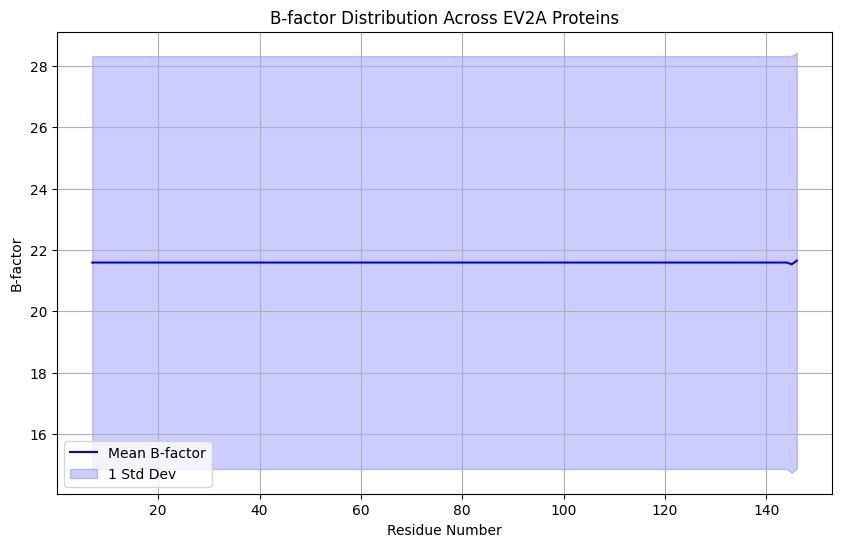

In [57]:
# Plot b-factors Distribution
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
plt.plot( residues_num, mean, label="Mean B-factor", color='blue')
plt.fill_between( residues_num, mean - std, mean + std, color='blue', alpha=0.2,
                 label="1 Std Dev" )
plt.xlabel("Residue Number")
plt.ylabel("B-factor")
plt.title("B-factor Distribution Across EV2A Proteins")
plt.legend()
plt.grid()
plt.show()

### Extract Average RMSE

In [ ]:
# Calculate Average Coordinates for each Residue
success_chains = [ lst_chains[idx] for idx in success_indices ]
chain_coords = [ [ get_atom_coord(res) for res in chain] for chain in success_chains]



# new_chain = []
# for chain in chain_coords:
#     if len(chain) < 140:
#         new_chain.append(chain + [np.nan] * (140 - len(chain)))
#     elif len(chain) > 140:
#         new_chain.append(chain[:140])
#     else:
#         new_chain.append(chain)

# new_chain = np.array(new_chain)



# Calculate Average RMSE

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 2 dimensions. The detected shape was (89, 140) + inhomogeneous part.

In [20]:
len(lst_prots[test_idx][0][get_ChainName(lst_prots[test_idx],0 ) ])

139

In [ ]:
prot_clone = prot.clone()
chain_names = [ chain.name for chain in prot_clone[0]]
for chain_name in chain_names: del  prot_clone[0][chain_name[0]]

print( prot[0])
print( prot_clone[0] )

<gemmi.Model 1 with 0 chain(s)>
<gemmi.Model 1 with 5 chain(s)>


In [10]:
nonactivepdbs_dir = rootdir / "data/ev2a/fragalysis/02-chemofint/nonactivesite"
fragscreen_dir = rootdir / "data/ev2a/fragalysis/02-chemofint/fragscreen"


In [22]:
print(type(lig_com[0]))

<class 'numpy.ndarray'>


In [23]:
pdb[0]["A"].calculate_center_of_mass().dist( gemmi.Position(*lig_com[0]))

39.321030417308506

In [26]:
pdb = gemmi.read_pdb(str(nonactivepdbs_dir / "A0514b/A0514b_apo-desolv.pdb"))
pdb2 = gemmi.read_pdb(str( fragscreen_dir/ "A0926a/A0926a.pdb"))
# print( pdb )
get_pdb_stats( pdb )
print("")
get_pdb_stats( pdb2 )

lig = sele_pdb( pdb2, "residue", sele_Lig)
lig_com = get_res_CoM(flatten_pdb(lig, "residue"))
lig_com = gemmi.Position(*lig_com[0])

prot = sele_pdb( pdb, "residue", sele_AA)
for chain in prot[0]:
    print( "Chain {} is {} A away from lig ".format(
        chain.name,chain.calculate_center_of_mass().dist(lig_com)) )

# print( lig_com)

Number of models: 1
Number of chains in 1st Model: 2

Chain ID: A
	Number of Residues: 140
	Unique List of Non-A.A.: set()
	Contains A.A.
Chain ID: B
	Number of Residues: 139
	Unique List of Non-A.A.: set()
	Contains A.A.

Number of models: 1
Number of chains in 1st Model: 4

Chain ID: A
	Number of Residues: 142
	Unique List of Non-A.A.: {'LIG', 'ZN'}
	Contains A.A.
Chain ID: B
	Number of Residues: 141
	Unique List of Non-A.A.: {'ZN'}
	Contains A.A.
Chain ID: C
	Number of Residues: 2
	Unique List of Non-A.A.: {'DMS'}
Chain ID: H
	Number of Residues: 9
	Unique List of Non-A.A.: {'HOH'}
Chain A is 39.321030417308506 A away from lig 
Chain B is 11.346976854363833 A away from lig 


In [ ]:
# Looking at sizes of non-active site proteins
dataset_names = [ folder.name for folder in nonactivepdbs_dir.iterdir() if folder.is_dir() ]
dataset_names.sort()
length = []
for dataset in dataset_names:
        file = nonactivepdbs_dir / "{}/{}_apo-desolv.pdb".format(dataset, dataset)
        try:
                pdb = gemmi.read_pdb(str( file))
        except:
                print( f"Error reading {dataset}" )
                continue
        length.append( len(pdb[0]["A"]) )

print( "Biggest non-active site PDB has {} residues".format( max(length) ) )



Error reading A7459a
Error reading A7465a
Error reading A7465b
Error reading A7475a
Error reading A7475b
Error reading A7491a
Error reading A7491b
Error reading A7501a
Error reading A7501b
Error reading A7510a
Error reading A7510b
Error reading A7515a
Error reading A7533a
Error reading A7533b
Biggest non-active site PDB has 140 residues


In [42]:
print( "Bound\n\tChain A {} Chain B {}".format(
                                pdb[0]["A"].calculate_center_of_mass(),
                                pdb[0]["B"].calculate_center_of_mass()  ) )

print( "Ground\n\tChain A {} Chain B {}".format(
                                pdb2[0]["A"].calculate_center_of_mass(),
                                pdb2[0]["B"].calculate_center_of_mass()  ) )


Bound
	Chain A <gemmi.Position(26.3926, -20.8283, 15.2044)> Chain B <gemmi.Position(14.7035, 7.00834, 15.001)>
Ground
	Chain A <gemmi.Position(23.9759, -21.4157, 16.5983)> Chain B <gemmi.Position(15.1131, 6.47028, 14.403)>


In [36]:
from xaidar.data.molecModels import get_atom_coord

res1 = pdb[0]["B"][10]
res2 = pdb2[0]["D"][10]
print( "Resiidue 10 in non-active site: {} {} | {} {}".format( 
    res1.seqid, res1.name, res2.seqid, res2.name) )

coord1 = get_atom_coord( res1)
print( coord1 )
coord2 = get_atom_coord( res2)
print( coord2 )
rmsd = np.sqrt( np.mean( np.sum( (coord1 - coord2)**2, axis=1) ) )
print( f"RMSD between residue 10 in non-active site and active site: {rmsd:.3f} Å" )




ValueError: Chain D not found (only [H])

In [38]:
set([ res.name for res in pdb[0]["A"]])

{'ALA',
 'ARG',
 'ASN',
 'ASP',
 'CYS',
 'GLN',
 'GLU',
 'GLY',
 'HIS',
 'ILE',
 'LEU',
 'LYS',
 'MET',
 'PHE',
 'PRO',
 'SER',
 'THR',
 'TRP',
 'TYR',
 'VAL'}